<a href="https://colab.research.google.com/github/ilfpns/PhoSem/blob/main/Phosem_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import os, re, glob, shutil, random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchvision.models as tv_models
from torchvision.models import Wide_ResNet50_2_Weights
from PIL import Image
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

PyTorch: 2.11.0+cu128
CUDA: True
Device: Tesla T4


In [12]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!apt-get -qq install fonts-nanum > /dev/null

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
fm.fontManager.addfont(font_path)
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print("폰트 설정 완료:", plt.rcParams['font.family'])

폰트 설정 완료: ['NanumGothic']


In [13]:
import os, re, glob, shutil, random
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torchvision.models as tv_models
from torchvision.models import Wide_ResNet50_2_Weights
from PIL import Image
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

if not any('Nanum' in f.name for f in fm.fontManager.ttflist):
    os.system("apt-get -qq install fonts-nanum > /dev/null 2>&1")
    fm.fontManager.addfont("/usr/share/fonts/truetype/nanum/NanumGothic.ttf")
plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

from google.colab import drive
drive.mount("/content/drive")

SRC = "/content/drive/MyDrive/all_data"
DATA_DIR = "/content/dataset"
if not os.path.exists(DATA_DIR) or len(os.listdir(DATA_DIR)) == 0:
    os.makedirs(DATA_DIR, exist_ok=True)
    IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp")
    copied, seen_names = 0, set()
    for root, dirs, files in os.walk(SRC, followlinks=False):
        dirs[:] = [d for d in dirs if not os.path.islink(os.path.join(root, d))]
        for f in files:
            if f.lower().endswith(IMG_EXTS) and f not in seen_names:
                shutil.copy2(os.path.join(root, f), os.path.join(DATA_DIR, f))
                seen_names.add(f)
                copied += 1
    print(f"복사 완료: {copied}장")
else:
    print(f"이미 준비됨: {len(os.listdir(DATA_DIR))}개 항목")

IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp")

def parse_filename(path):
    name = os.path.splitext(os.path.basename(path))[0].lower()
    m = re.match(r"^(\d+)[-_]([ox])(.*)$", name)
    if not m:
        return None
    num, ox, rest = m.groups()
    return {"path": path, "num": int(num),
            "label": "good" if ox == "o" else "bad",
            "is_die": "die" in rest}

all_files = sorted(p for p in glob.glob(os.path.join(DATA_DIR, "**", "*"), recursive=True)
                   if p.lower().endswith(IMG_EXTS))
parsed = [info for p in all_files if (info := parse_filename(p))]
die_files = [f for f in parsed if f["is_die"]]
good_paths = sorted(f["path"] for f in die_files if f["label"] == "good")
bad_paths = sorted(f["path"] for f in die_files if f["label"] == "bad")
print(f"양품 {len(good_paths)} / 불량 {len(bad_paths)}")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

random.seed(42)
shuffled_good = good_paths.copy()
random.shuffle(shuffled_good)
split = int(len(shuffled_good) * 0.8)
bank_good = shuffled_good[:split]
val_good = shuffled_good[split:]
print(f"뱅크용 양품 {len(bank_good)} / 검증용(held-out) {len(val_good)}")

PATCH_INPUT_SIZE = 512
POOL_KERNEL = 1   # 1=지역평균 생략(파티클 신호 보존), 3=원래 기본값

def load_for_patchcore(path, size=PATCH_INPUT_SIZE):
    img = Image.open(path).convert("RGB")
    orig_size = img.size
    img = img.resize((size, size), Image.BILINEAR)
    return TF.to_tensor(img).unsqueeze(0).to(DEVICE), orig_size

class PatchFeatureExtractor(torch.nn.Module):
    def __init__(self, device=DEVICE, pool_kernel=POOL_KERNEL):
        super().__init__()
        backbone = tv_models.wide_resnet50_2(weights=Wide_ResNet50_2_Weights.IMAGENET1K_V1)
        backbone.eval()
        for p in backbone.parameters():
            p.requires_grad = False
        self.backbone = backbone.to(device)
        self.pool_kernel = pool_kernel
        self._feat = {}
        self.backbone.layer2.register_forward_hook(self._hook('layer2'))
        self.backbone.layer3.register_forward_hook(self._hook('layer3'))

    def _hook(self, name):
        def fn(module, inp, out):
            self._feat[name] = out
        return fn

    @torch.no_grad()
    def forward(self, x):
        self._feat = {}
        _ = self.backbone(x)
        f2, f3 = self._feat['layer2'], self._feat['layer3']
        f3_up = F.interpolate(f3, size=f2.shape[-2:], mode='bilinear', align_corners=False)
        combined = torch.cat([f2, f3_up], dim=1)
        pad = self.pool_kernel // 2
        return F.avg_pool2d(combined, kernel_size=self.pool_kernel, stride=1, padding=pad)

extractor = PatchFeatureExtractor(pool_kernel=POOL_KERNEL)
print(f"extractor 준비 (PATCH_INPUT_SIZE={PATCH_INPUT_SIZE}, POOL_KERNEL={POOL_KERNEL})")

@torch.no_grad()
def patchcore_score(path, memory_bank, extractor, size=PATCH_INPUT_SIZE, chunk=2048):
    x, orig_size = load_for_patchcore(path, size)
    feat = extractor(x)
    B, C, H, W = feat.shape
    patches = feat.permute(0, 2, 3, 1).reshape(H*W, C)
    dists = []
    for i in range(0, patches.shape[0], chunk):
        d = torch.cdist(patches[i:i+chunk], memory_bank)
        dists.append(d.min(dim=1).values)
    dists = torch.cat(dists)
    heatmap = F.interpolate(dists.reshape(1,1,H,W), size=(size,size),
                            mode='bilinear', align_corners=False)
    return heatmap.squeeze().cpu().numpy(), dists.max().item(), orig_size

def sweep_threshold(df, n=50):
    ths = np.linspace(df.이상점수.min(), df.이상점수.max(), n)
    rows = []
    for th in ths:
        pred_bad = df.이상점수 > th
        actual_bad = df.실제 == '불량'
        tp = (pred_bad & actual_bad).sum(); fn = (~pred_bad & actual_bad).sum()
        fp = (pred_bad & ~actual_bad).sum(); tn = (~pred_bad & ~actual_bad).sum()
        rows.append({'threshold': round(th,2), 'accuracy': round((tp+tn)/len(df),3),
                     '불량_recall': round(tp/(tp+fn),3) if tp+fn else 0,
                     '놓친_불량': fn, '과검_양품': fp})
    return pd.DataFrame(rows)

print("초기화 완료")

Mounted at /content/drive
복사 완료: 502장
양품 117 / 불량 133
Device: cuda
뱅크용 양품 93 / 검증용(held-out) 24
extractor 준비 (PATCH_INPUT_SIZE=512, POOL_KERNEL=1)
초기화 완료


In [14]:
import os, glob, shutil

SRC = "/content/drive/MyDrive/all_data"
DATA_DIR = "/content/dataset"

if os.path.exists(DATA_DIR):
    shutil.rmtree(DATA_DIR)
os.makedirs(DATA_DIR)

IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp")

# 심볼릭 링크는 따라가지 않고, 실제 파일 목록만 os.walk로 수집
copied, seen_names = 0, set()
for root, dirs, files in os.walk(SRC, followlinks=False):
    # 링크로 만들어진 하위 디렉토리는 아예 내려가지 않도록 제거
    dirs[:] = [d for d in dirs if not os.path.islink(os.path.join(root, d))]
    for f in files:
        if f.lower().endswith(IMG_EXTS) and f not in seen_names:
            shutil.copy2(os.path.join(root, f), os.path.join(DATA_DIR, f))
            seen_names.add(f)
            copied += 1

print(f"복사 완료: {copied}장 (중복 이름 제외)")

복사 완료: 502장 (중복 이름 제외)


In [15]:
import os

repo_path = "/content/Phosem-CNN-Problem-Detection"
if not os.path.exists(repo_path):
    !git clone https://github.com/Phosem/Phosem-CNN-Problem-Detection.git {repo_path}
    print(f"Repository cloned to {repo_path}")
else:
    print(f"Repository already exists at {repo_path}")

if os.path.exists(os.path.join(repo_path, 'data_loader.py')):
    print("data_loader.py found.")
else:
    print("Error: data_loader.py not found in the cloned repository.")

Cloning into '/content/Phosem-CNN-Problem-Detection'...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 6 (delta 0), reused 6 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (6/6), done.
Repository cloned to /content/Phosem-CNN-Problem-Detection
data_loader.py found.


In [16]:
import re

def parse_filename(path):
    name = os.path.splitext(os.path.basename(path))[0].lower()
    m = re.match(r"^(\d+)[-_]([ox])(.*)$", name)
    if not m:
        return None
    num, ox, rest = m.groups()
    return {"path": path, "num": int(num),
            "label": "good" if ox == "o" else "bad",
            "is_die": "die" in rest}

all_files = sorted(p for p in glob.glob(os.path.join(DATA_DIR, "**", "*"), recursive=True)
                   if p.lower().endswith(IMG_EXTS))
parsed   = [info for p in all_files if (info := parse_filename(p))]
unparsed = [p for p in all_files if parse_filename(p) is None]
die_files = [f for f in parsed if f["is_die"]]
good_paths = sorted(f["path"] for f in die_files if f["label"] == "good")
bad_paths  = sorted(f["path"] for f in die_files if f["label"] == "bad")

print(f"전체 {len(all_files)}장 | die 사용 {len(die_files)}장 → 양품 {len(good_paths)} / 불량 {len(bad_paths)}")
print(f"제외: die 미포함 {len(parsed)-len(die_files)}장, 규칙 불일치 {len(unparsed)}장")
for p in unparsed[:10]:
    print("  [규칙 불일치]", os.path.basename(p))

전체 502장 | die 사용 250장 → 양품 117 / 불량 133
제외: die 미포함 250장, 규칙 불일치 2장
  [규칙 불일치] 445-0.jpg
  [규칙 불일치] 445-0_die800.jpg


In [17]:
import re

IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp")

def parse_filename(path):
    """
    '429-x_die800.png' → {'num': 429, 'label': 'bad', 'is_die': True}
    '431-o.png'        → {'num': 431, 'label': 'good', 'is_die': False}
    규칙에 안 맞으면 None
    """
    name = os.path.splitext(os.path.basename(path))[0].lower()
    m = re.match(r"^(\d+)[-_]([ox])(.*)$", name)
    if not m:
        return None
    num, ox, rest = m.groups()
    return {
        "path": path,
        "num": int(num),
        "label": "good" if ox == "o" else "bad",
        "is_die": "die" in rest,
    }

all_files = sorted(
    p for p in glob.glob(os.path.join(DATA_DIR, "**", "*"), recursive=True)
    if p.lower().endswith(IMG_EXTS)
)

parsed    = [info for p in all_files if (info := parse_filename(p))]
unparsed  = [p for p in all_files if parse_filename(p) is None]

die_files  = [f for f in parsed if f["is_die"]]
good_paths = sorted(f["path"] for f in die_files if f["label"] == "good")
bad_paths  = sorted(f["path"] for f in die_files if f["label"] == "bad")

print(f"전체 이미지        : {len(all_files)}장")
print(f"  ├ die 포함(사용) : {len(die_files)}장  →  양품 {len(good_paths)} / 불량 {len(bad_paths)}")
print(f"  ├ die 미포함(제외): {len(parsed) - len(die_files)}장")
print(f"  └ 규칙 불일치     : {len(unparsed)}장")

if unparsed:
    print("\n[확인 필요] 파일명 규칙에 안 맞는 파일:")
    for p in unparsed[:10]:
        print("   ", os.path.basename(p))

assert good_paths, "양품(die) 이미지가 없습니다 — PatchCore 메모리 뱅크에 필수"
print("\n양품 예시:", [os.path.basename(p) for p in good_paths[:3]])
print("불량 예시:", [os.path.basename(p) for p in bad_paths[:3]])

전체 이미지        : 502장
  ├ die 포함(사용) : 250장  →  양품 117 / 불량 133
  ├ die 미포함(제외): 250장
  └ 규칙 불일치     : 2장

[확인 필요] 파일명 규칙에 안 맞는 파일:
    445-0.jpg
    445-0_die800.jpg

양품 예시: ['278-o_die800.jpg', '279-o_die800.jpg', '280-o_die800.jpg']
불량 예시: ['276-x_die800.jpg', '277-x_die800.jpg', '283-x_die800.jpg']


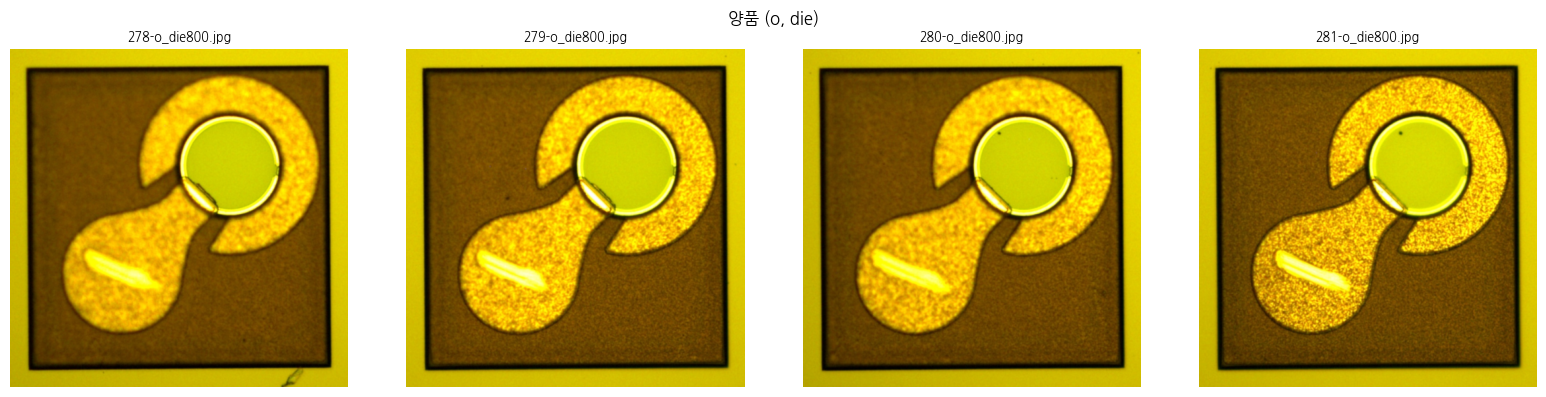

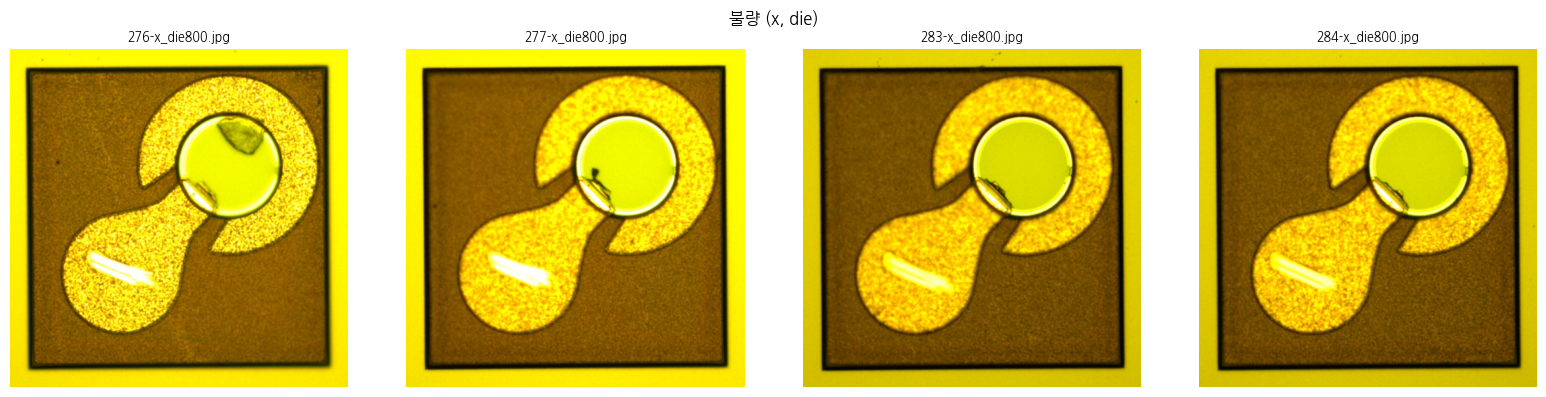

In [18]:
import sys, importlib
import matplotlib.pyplot as plt
import os

sys.path.insert(0, "/content/Phosem-CNN-Problem-Detection")
importlib.invalidate_caches()
from data_loader import load_image_gpu, load_batch_gpu, scan_dataset

def show_row(paths, title, n=4):
    n = min(n, len(paths))
    if n == 0:
        print(f"{title}: 없음"); return
    fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    axes = [axes] if n == 1 else axes
    for ax, p in zip(axes, paths[:n]):
        t, _ = load_image_gpu(p)
        ax.imshow(t[0].permute(1, 2, 0).cpu().numpy())
        ax.set_title(os.path.basename(p), fontsize=9); ax.axis("off")
    fig.suptitle(title); plt.tight_layout(); plt.show()

show_row(good_paths, "양품 (o, die)")
show_row(bad_paths,  "불량 (x, die)")

In [19]:
import random
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from PIL import Image

IMG_SIZE = 256
class DieDataset(Dataset):
    def __init__(self, paths, labels, train=True):
        self.paths, self.labels = paths, labels
        if train:
            self.tf = T.Compose([
                T.Resize((IMG_SIZE, IMG_SIZE)),
                T.RandomHorizontalFlip(),
                T.RandomVerticalFlip(),
                T.RandomRotation(10),
                T.ColorJitter(brightness=0.2, contrast=0.2),
                T.ToTensor(),
            ])
        else:
            self.tf = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE)), T.ToTensor()])

    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.tf(img), self.labels[i]

all_paths  = good_paths + bad_paths
all_labels = [0]*len(good_paths) + [1]*len(bad_paths)

idx = list(range(len(all_paths)))
random.seed(42); random.shuffle(idx)
split = int(len(idx)*0.8)
tr_idx, va_idx = idx[:split], idx[split:]

train_ds = DieDataset([all_paths[i] for i in tr_idx], [all_labels[i] for i in tr_idx], train=True)
val_ds   = DieDataset([all_paths[i] for i in va_idx], [all_labels[i] for i in va_idx], train=False)
train_dl = DataLoader(train_ds, batch_size=8, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=8)

print(f"학습 {len(train_ds)}장 / 검증 {len(val_ds)}장")
print(f"검증 세트 불량 비율: {sum(all_labels[i] for i in va_idx)}/{len(va_idx)}")

학습 200장 / 검증 50장
검증 세트 불량 비율: 26/50


In [20]:
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [21]:
import torch.nn as nn

def build_cnn(channels=[16, 32, 64], num_classes=2, in_size=IMG_SIZE):
    """channels 리스트 = 각 conv층 채널 수. 리스트 길이 = 층수(깊이)"""
    layers, in_ch = [], 3
    for out_ch in channels:
        layers += [
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        ]
        in_ch = out_ch
    layers += [nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Linear(in_ch, num_classes)]
    return nn.Sequential(*layers)

model = build_cnn([16, 32, 64, 128]).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"파라미터 수: {n_params:,}")

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU(inplace=True)
  (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU(inplace=True)
  (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (12): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (14): ReLU(inplac

In [22]:
def train_model(model, train_dl, val_dl, epochs=30, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss()
    best_acc, history = 0, []

    for ep in range(1, epochs+1):
        model.train(); tr_loss = 0
        for x, y in train_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward(); opt.step()
            tr_loss += loss.item() * len(x)

        # 검증
        model.eval(); correct = total = 0
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                correct += (model(x).argmax(1) == y).sum().item()
                total += len(x)
        acc = correct / total
        history.append((tr_loss/len(train_dl.dataset), acc))
        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_classifier.pth")
        print(f"epoch {ep:2d} | loss {history[-1][0]:.4f} | val acc {acc:.3f}"
              + (" *" if acc == best_acc else ""))

    print(f"\n최고 검증 정확도: {best_acc:.3f} → best_classifier.pth 저장됨")
    return history

history = train_model(model, train_dl, val_dl)

epoch  1 | loss 0.7500 | val acc 0.540 *
epoch  2 | loss 0.7028 | val acc 0.520
epoch  3 | loss 0.6984 | val acc 0.520
epoch  4 | loss 0.7052 | val acc 0.520
epoch  5 | loss 0.6805 | val acc 0.540 *
epoch  6 | loss 0.6844 | val acc 0.500
epoch  7 | loss 0.6654 | val acc 0.460
epoch  8 | loss 0.6764 | val acc 0.680 *
epoch  9 | loss 0.6619 | val acc 0.500
epoch 10 | loss 0.6698 | val acc 0.540
epoch 11 | loss 0.7018 | val acc 0.520
epoch 12 | loss 0.6767 | val acc 0.580
epoch 13 | loss 0.6894 | val acc 0.520
epoch 14 | loss 0.6784 | val acc 0.660
epoch 15 | loss 0.6695 | val acc 0.720 *
epoch 16 | loss 0.6859 | val acc 0.520
epoch 17 | loss 0.6595 | val acc 0.500
epoch 18 | loss 0.6581 | val acc 0.580
epoch 19 | loss 0.6552 | val acc 0.660
epoch 20 | loss 0.6485 | val acc 0.740 *
epoch 21 | loss 0.6569 | val acc 0.520
epoch 22 | loss 0.6799 | val acc 0.560
epoch 23 | loss 0.6702 | val acc 0.520
epoch 24 | loss 0.6741 | val acc 0.580
epoch 25 | loss 0.6383 | val acc 0.520
epoch 26 | loss

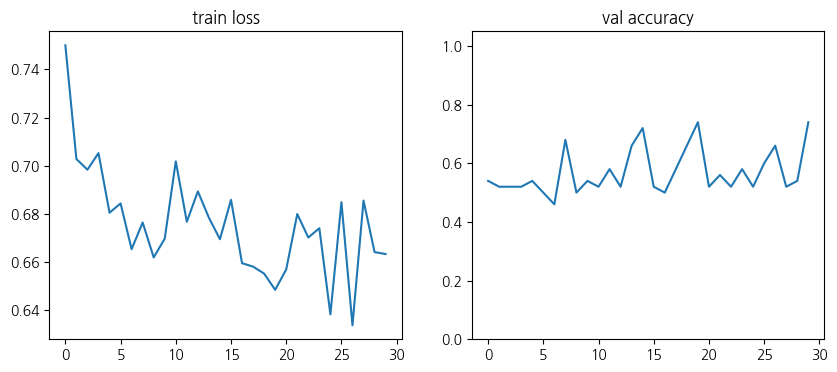

파일                                       정답   예측   불량확률
506-x_die800.jpg                         불량   불량   0.51
536-o_die800.jpg                         양품   양품   0.28
442-x_die800.jpg                         불량   불량   0.57
484-x_die800.jpg                         불량   불량   0.65
402-o_die800.jpg                         양품   양품   0.31
469-x_die800.jpg                         불량   불량   0.62
537-o_die800.jpg                         양품   양품   0.46
488-x_die800.jpg                         불량   양품   0.45  ← 오답
411-x_die800.jpg                         불량   불량   0.58
404-o_die800.jpg                         양품   양품   0.40
461-x_die800.jpg                         불량   양품   0.44  ← 오답
441-x_die800.jpg                         불량   불량   0.60
279-o_die800.jpg                         양품   양품   0.44
462-x_die800.jpg                         불량   양품   0.46  ← 오답
521-o_die800.jpg                         양품   양품   0.30
335-x_die800.jpg                         불량   불량   0.70
564-o_die800.jpg              

In [23]:
losses, accs = zip(*history)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(losses); ax[0].set_title("train loss")
ax[1].plot(accs); ax[1].set_title("val accuracy"); ax[1].set_ylim(0, 1.05)
plt.show()

# 검증 이미지별 판정 결과
model.load_state_dict(torch.load("best_classifier.pth"))
model.eval()
print(f"{'파일':40s} 정답   예측   불량확률")
with torch.no_grad():
    for i in va_idx:
        x = val_ds.tf(Image.open(all_paths[i]).convert("RGB")).unsqueeze(0).to(DEVICE)
        prob = torch.softmax(model(x), 1)[0, 1].item()
        gt, pred = ["양품","불량"][all_labels[i]], ["양품","불량"][prob > 0.5]
        mark = "" if gt == pred else "  ← 오답"
        print(f"{os.path.basename(all_paths[i]):40s} {gt}   {pred}   {prob:.2f}{mark}")

In [24]:
import pandas as pd
import numpy as np

model.load_state_dict(torch.load("best_classifier.pth"))
model.eval()

rows = []
with torch.no_grad():
    for i in va_idx:
        x = val_ds.tf(Image.open(all_paths[i]).convert("RGB")).unsqueeze(0).to(DEVICE)
        prob = torch.softmax(model(x), 1)[0, 1].item()
        rows.append({
            "파일": os.path.basename(all_paths[i]),
            "정답": ["양품", "불량"][all_labels[i]],
            "예측": ["양품", "불량"][int(prob > 0.5)],
            "불량확률": round(prob, 3),
            "판정": "O" if (prob > 0.5) == bool(all_labels[i]) else "X",
        })

df = pd.DataFrame(rows).sort_values("불량확률", ascending=False).reset_index(drop=True)
display(df)

cm = pd.crosstab(df["정답"], df["예측"], rownames=["정답"], colnames=["예측"])
display(cm)

tp = len(df[(df.정답=="불량") & (df.예측=="불량")])
fn = len(df[(df.정답=="불량") & (df.예측=="양품")])
fp = len(df[(df.정답=="양품") & (df.예측=="불량")])
tn = len(df[(df.정답=="양품") & (df.예측=="양품")])

summary = pd.DataFrame({
    "지표": ["정확도", "불량 검출률 (recall)", "불량 예측 정밀도 (precision)", "과검률 (양품→불량 오판)"],
    "값": [
        f"{(tp+tn)/len(df):.1%}",
        f"{tp/(tp+fn):.1%}" if tp+fn else "-",
        f"{tp/(tp+fp):.1%}" if tp+fp else "-",
        f"{fp/(fp+tn):.1%}" if fp+tn else "-",
    ],
})
display(summary)

,파일,정답,예측,불량확률,판정
0,416-x_die800.jpg,불량,불량,0.854,O
1,336-o_die800.jpg,양품,불량,0.759,X
2,493-o_die800.jpg,양품,불량,0.717,X
3,564-o_die800.jpg,양품,불량,0.711,X
4,335-x_die800.jpg,불량,불량,0.696,O
5,412-x_die800.jpg,불량,불량,0.662,O
6,483-x_die800.jpg,불량,불량,0.656,O
7,484-x_die800.jpg,불량,불량,0.650,O
8,492-x_die800.jpg,불량,불량,0.649,O
9,360-o_die800.jpg,양품,불량,0.637,X


예측,불량,양품
정답,,
불량,23,3
양품,10,14


,지표,값
0,정확도,74.0%
1,불량 검출률 (recall),88.5%
2,불량 예측 정밀도 (precision),69.7%
3,과검률 (양품→불량 오판),41.7%


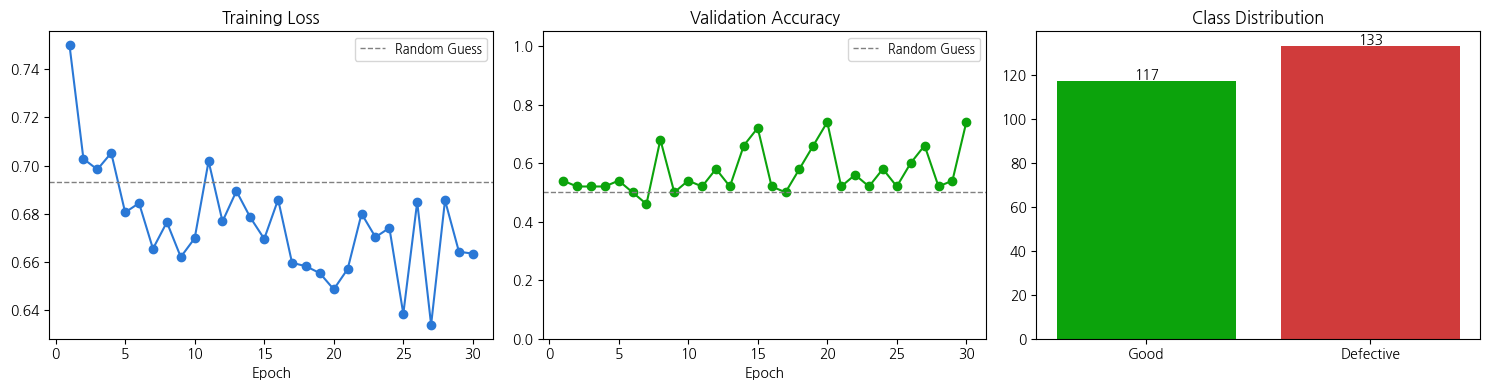

Final Epoch: Loss 0.6633 | Validation Accuracy 0.740
Best Validation Accuracy: 0.740 (Epoch 20)
Class Ratio: Good 117 : Defective 133 (Ratio 0.88:1)


In [25]:
import matplotlib.pyplot as plt

assert 'history' in globals(), "history not found — run the training cell (train_model) first."
assert 'good_paths' in globals() and 'bad_paths' in globals(), \
    "good_paths/bad_paths not found — run the dataset scanning cell first."

losses, accs = zip(*history)
epochs = list(range(1, len(history) + 1))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, losses, marker='o', color='#2a78d6')
axes[0].axhline(0.693, color='gray', linestyle='--', linewidth=1, label='Random Guess')
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend(fontsize=9)

axes[1].plot(epochs, accs, marker='o', color='#0ca30c')
axes[1].axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Random Guess')
axes[1].set_ylim(0, 1.05)
axes[1].set_title("Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend(fontsize=9)

counts = [len(good_paths), len(bad_paths)]
bars = axes[2].bar(["Good", "Defective"], counts, color=["#0ca30c", "#d03b3b"])
axes[2].set_title("Class Distribution")
for b, c in zip(bars, counts):
    axes[2].text(b.get_x() + b.get_width()/2, c + 1, str(c), ha='center')

plt.tight_layout()
plt.show()

print(f"Final Epoch: Loss {losses[-1]:.4f} | Validation Accuracy {accs[-1]:.3f}")
print(f"Best Validation Accuracy: {max(accs):.3f} (Epoch {accs.index(max(accs)) + 1})")
print(
    f"Class Ratio: Good {counts[0]} : Defective {counts[1]} "
    f"(Ratio {counts[0] / counts[1]:.2f}:1)"
    if counts[1]
    else "No defective samples."
)

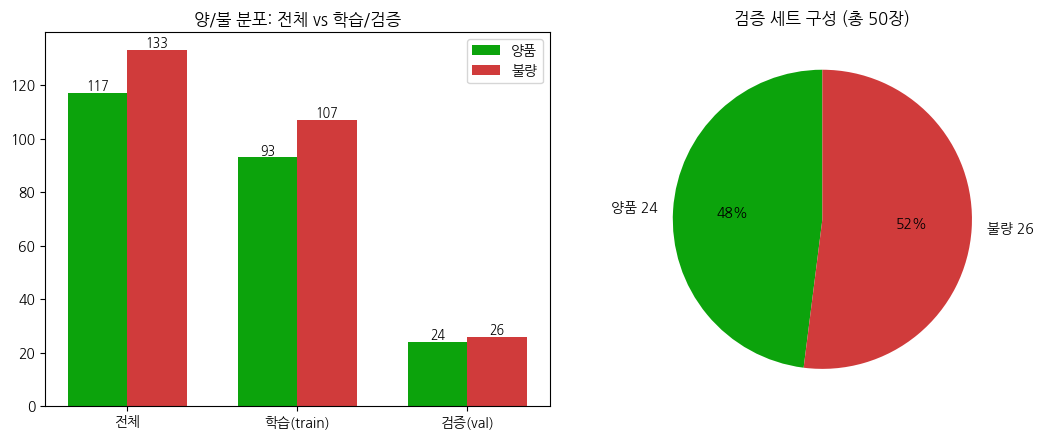

전체: 양품 117 / 불량 133  (비율 0.88:1)
학습: 양품 93 / 불량 107
검증: 양품 24 / 불량 26


In [26]:
import matplotlib.pyplot as plt
import numpy as np

assert 'all_labels' in globals() and 'tr_idx' in globals() and 'va_idx' in globals(), \
    "all_labels/tr_idx/va_idx 없음 — 데이터셋 분할 셀 먼저 실행"

train_labels = [all_labels[i] for i in tr_idx]
val_labels = [all_labels[i] for i in va_idx]
train_good, train_bad = train_labels.count(0), train_labels.count(1)
val_good, val_bad = val_labels.count(0), val_labels.count(1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

x = np.arange(3)
width = 0.35
good_counts = [len(good_paths), train_good, val_good]
bad_counts = [len(bad_paths), train_bad, val_bad]

axes[0].bar(x - width/2, good_counts, width, label='양품', color='#0ca30c')
axes[0].bar(x + width/2, bad_counts, width, label='불량', color='#d03b3b')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['전체', '학습(train)', '검증(val)'])
axes[0].set_title("양/불 분포: 전체 vs 학습/검증")
axes[0].legend()
for i, (g, b) in enumerate(zip(good_counts, bad_counts)):
    axes[0].text(i - width/2, g + 1, str(g), ha='center', fontsize=9)
    axes[0].text(i + width/2, b + 1, str(b), ha='center', fontsize=9)

axes[1].pie([val_good, val_bad], labels=[f'양품 {val_good}', f'불량 {val_bad}'],
            colors=['#0ca30c', '#d03b3b'], autopct='%1.0f%%', startangle=90)
axes[1].set_title(f"검증 세트 구성 (총 {len(val_labels)}장)")

plt.tight_layout()
plt.show()

print(f"전체: 양품 {len(good_paths)} / 불량 {len(bad_paths)}  (비율 {len(good_paths)/max(len(bad_paths),1):.2f}:1)")
print(f"학습: 양품 {train_good} / 불량 {train_bad}")
print(f"검증: 양품 {val_good} / 불량 {val_bad}")

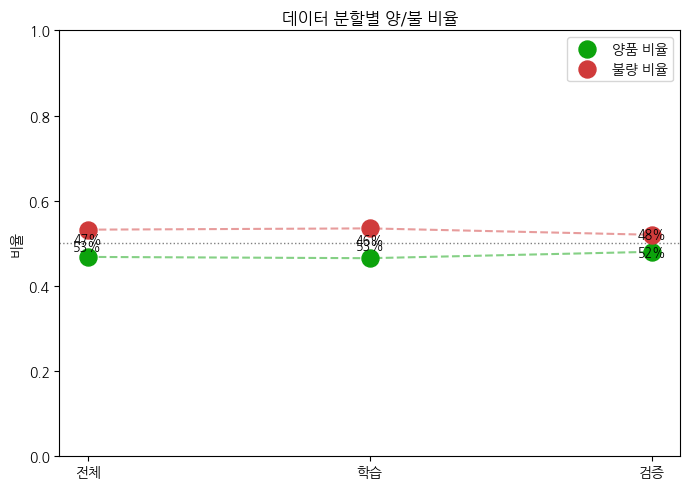

In [27]:
import matplotlib.pyplot as plt
import numpy as np

assert 'all_labels' in globals() and 'tr_idx' in globals() and 'va_idx' in globals(), "먼저 분할 셀 실행"

train_labels = [all_labels[i] for i in tr_idx]
val_labels = [all_labels[i] for i in va_idx]

splits = ['전체', '학습', '검증']
good_ratio = [
    len(good_paths) / (len(good_paths) + len(bad_paths)),
    train_labels.count(0) / len(train_labels),
    val_labels.count(0) / len(val_labels),
]
bad_ratio = [1 - g for g in good_ratio]
x = np.arange(len(splits))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x, good_ratio, color='#0ca30c', linestyle='--', alpha=0.5)
ax.scatter(x, good_ratio, s=150, color='#0ca30c', label='양품 비율', zorder=3)
ax.plot(x, bad_ratio, color='#d03b3b', linestyle='--', alpha=0.5)
ax.scatter(x, bad_ratio, s=150, color='#d03b3b', label='불량 비율', zorder=3)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(splits)
ax.set_ylim(0, 1)
ax.set_ylabel('비율')
ax.set_title('데이터 분할별 양/불 비율')
ax.legend()

for i, (g, b) in enumerate(zip(good_ratio, bad_ratio)):
    ax.annotate(f'{g:.0%}', (x[i], g), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
    ax.annotate(f'{b:.0%}', (x[i], b), textcoords="offset points", xytext=(0, -15), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [28]:
def find_recall_threshold(model, val_dl, target_recall=1.0):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for x, y in val_dl:
            p = torch.softmax(model(x.to(DEVICE)), 1)[:, 1].cpu()
            probs.extend(p.tolist()); labels.extend(y.tolist())
    probs, labels = np.array(probs), np.array(labels)

    rows = []
    for th in np.arange(0.05, 0.55, 0.05):
        pred = (probs > th).astype(int)
        tp = ((pred==1)&(labels==1)).sum(); fn = ((pred==0)&(labels==1)).sum()
        fp = ((pred==1)&(labels==0)).sum(); tn = ((pred==0)&(labels==0)).sum()
        recall = tp/(tp+fn) if tp+fn else 0
        rows.append({"threshold": round(th,2), "불량_recall": round(recall,3),
                     "놓친_불량": fn, "과검_양품": fp})
    df = pd.DataFrame(rows)
    display(df)
    ok = df[df.불량_recall >= target_recall]
    if len(ok):
        best = ok.iloc[ok.과검_양품.argmin()]
        print(f"\nrecall {target_recall} 달성하는 최고 threshold: {best.threshold} (과검 {best.과검_양품}건)")
    else:
        print(f"\n어떤 threshold로도 recall {target_recall} 달성 불가 — 모델 자체를 더 학습/개선 필요")
    return df

find_recall_threshold(model, val_dl, target_recall=1.0)

,threshold,불량_recall,놓친_불량,과검_양품
0,0.05,1.000,0,24
1,0.10,1.000,0,24
2,0.15,1.000,0,24
3,0.20,1.000,0,24
4,0.25,1.000,0,24
5,0.30,1.000,0,21
6,0.35,1.000,0,20
7,0.40,1.000,0,17
8,0.45,0.923,2,14
9,0.50,0.885,3,10



recall 1.0 달성하는 최고 threshold: 0.4 (과검 17.0건)


,threshold,불량_recall,놓친_불량,과검_양품
0,0.05,1.000,0,24
1,0.10,1.000,0,24
2,0.15,1.000,0,24
3,0.20,1.000,0,24
4,0.25,1.000,0,24
5,0.30,1.000,0,21
6,0.35,1.000,0,20
7,0.40,1.000,0,17
8,0.45,0.923,2,14
9,0.50,0.885,3,10


In [29]:
if 'bank_good' not in globals():
    import random
    random.seed(42)
    shuffled_good = good_paths.copy()
    random.shuffle(shuffled_good)
    split = int(len(shuffled_good) * 0.8)
    bank_good = shuffled_good[:split]
    val_good = shuffled_good[split:]
    print(f"뱅크용 양품 {len(bank_good)}장 / 검증용(held-out) {len(val_good)}장")

PER_IMAGE_SAMPLE = 800
batch_size = 4

raw_patches = []
for i in range(0, len(bank_good), batch_size):
    batch = bank_good[i:i+batch_size]
    imgs = torch.cat([load_for_patchcore(p)[0] for p in batch], dim=0)
    feats = extractor(imgs)
    B, C, H, W = feats.shape
    feats = feats.permute(0, 2, 3, 1).reshape(B, H*W, C)
    for b in range(B):
        idx = torch.randperm(H*W)[:PER_IMAGE_SAMPLE]
        raw_patches.append(feats[b, idx].cpu())
    if (i // batch_size) % 20 == 0:
        print(f"{min(i+batch_size, len(bank_good))}/{len(bank_good)}장")

raw_patches = torch.cat(raw_patches, dim=0)
memory_bank = raw_patches.to(DEVICE)
print(f"수집된 패치: {raw_patches.shape[0]:,}개 (grid {H}x{W}, PATCH_INPUT_SIZE={PATCH_INPUT_SIZE})")
print(f"메모리 뱅크: {tuple(memory_bank.shape)}")

4/93장
84/93장
수집된 패치: 74,400개 (grid 64x64, PATCH_INPUT_SIZE=512)
메모리 뱅크: (74400, 1536)


In [30]:
import pandas as pd
import numpy as np

assert 'memory_bank' in globals()

results = []
for label, paths in [('양품', good_paths), ('불량', bad_paths)]:
    for p in paths:
        _, score, _ = patchcore_score(p, memory_bank, extractor)
        results.append({'파일': os.path.basename(p), '실제': label, '이상점수': score})

df = pd.DataFrame(results).sort_values('이상점수', ascending=False).reset_index(drop=True)
display(df)

def sweep_threshold(df, n=50):
    ths = np.linspace(df.이상점수.min(), df.이상점수.max(), n)
    rows = []
    for th in ths:
        pred_bad = df.이상점수 > th
        actual_bad = df.실제 == '불량'
        tp = (pred_bad & actual_bad).sum(); fn = (~pred_bad & actual_bad).sum()
        fp = (pred_bad & ~actual_bad).sum(); tn = (~pred_bad & ~actual_bad).sum()
        rows.append({'threshold': round(th,2), 'accuracy': round((tp+tn)/len(df),3),
                     '불량_recall': round(tp/(tp+fn),3) if tp+fn else 0,
                     '놓친_불량': fn, '과검_양품': fp})
    return pd.DataFrame(rows)

sweep = sweep_threshold(df)
display(sweep.sort_values('accuracy', ascending=False).head(10))
print(f"\n최고 accuracy: {sweep.accuracy.max():.1%}")

,파일,실제,이상점수
0,412-x_die800.jpg,불량,6.039506
1,297-o_die800.jpg,양품,5.938708
2,510-x_die800.jpg,불량,5.655097
3,313-x_die800.jpg,불량,5.640966
4,507-x_die800.jpg,불량,5.421524
...,...,...,...
245,519-o_die800.jpg,양품,2.670596
246,520-o_die800.jpg,양품,2.670202
247,554-o_die800.jpg,양품,2.665702
248,535-o_die800.jpg,양품,2.662822


,threshold,accuracy,불량_recall,놓친_불량,과검_양품
13,3.46,0.696,0.714,38,38
12,3.38,0.696,0.752,33,43
10,3.24,0.684,0.827,23,56
11,3.31,0.684,0.789,28,51
6,2.95,0.680,0.962,5,75
14,3.53,0.680,0.662,45,35
15,3.60,0.672,0.609,52,30
9,3.17,0.660,0.842,21,64
7,3.03,0.656,0.910,12,74
5,2.88,0.656,0.977,3,83



최고 accuracy: 69.6%


In [31]:
class PatchFeatureExtractor(torch.nn.Module):
    def __init__(self, device=DEVICE, pool_kernel=1):
        super().__init__()
        backbone = tv_models.wide_resnet50_2(weights=Wide_ResNet50_2_Weights.IMAGENET1K_V1)
        backbone.eval()
        for p in backbone.parameters():
            p.requires_grad = False
        self.backbone = backbone.to(device)
        self.pool_kernel = pool_kernel
        self._feat = {}
        self.backbone.layer2.register_forward_hook(self._hook('layer2'))
        self.backbone.layer3.register_forward_hook(self._hook('layer3'))

    def _hook(self, name):
        def fn(module, inp, out):
            self._feat[name] = out
        return fn

    @torch.no_grad()
    def forward(self, x):
        self._feat = {}
        _ = self.backbone(x)
        f2, f3 = self._feat['layer2'], self._feat['layer3']
        f3_up = F.interpolate(f3, size=f2.shape[-2:], mode='nearest')
        combined = torch.cat([f2, f3_up], dim=1)
        pad = self.pool_kernel // 2
        return F.avg_pool2d(combined, kernel_size=self.pool_kernel, stride=1, padding=pad)

extractor = PatchFeatureExtractor(pool_kernel=1)  # kernel size 조정

In [32]:
import torch

def g(name, default="—"):
    return globals().get(name, default)

print("="*60)
print("사용 AI 모델")
print("="*60)
print(f"백본            : Wide ResNet-50-2 (ImageNet 사전학습)")
print(f"특징 추출 레이어 : layer2 + layer3 (업샘플 후 concat)")
if 'extractor' in globals():
    n_params = sum(p.numel() for p in extractor.backbone.parameters())
    n_trainable = sum(p.numel() for p in extractor.backbone.parameters() if p.requires_grad)
    print(f"전체 파라미터    : {n_params:,}")
    print(f"학습 가능 파라미터: {n_trainable:,}  (0이어야 정상 — 사전학습 고정)")
else:
    print("extractor        : 미실행")

print()
print("="*60)
print("데이터 전처리 / 커널 설정")
print("="*60)
print(f"PATCH_INPUT_SIZE       : {g('PATCH_INPUT_SIZE')}")
print(f"PATCH_INPUT_SIZE_T1    : {g('PATCH_INPUT_SIZE_T1')}")
print(f"PATCH_INPUT_SIZE_T2    : {g('PATCH_INPUT_SIZE_T2')}")
print(f"POOL_KERNEL (지역평균) : {g('POOL_KERNEL')}  (avg_pool2d kernel_size)")
print(f"라플라시안 커널 (블러)  : 3x3, [[0,1,0],[1,-4,1],[0,1,0]]")
print(f"이미지 정규화          : ToTensor만 적용, [0,1] 범위 (ImageNet mean/std 정규화 미적용)")

print()
print("="*60)
print("메모리 뱅크")
print("="*60)
for name in ['memory_bank', 'memory_bank_t1', 'memory_bank_t2']:
    if name in globals():
        mb = globals()[name]
        print(f"{name:20s}: shape {tuple(mb.shape)}  (패치 수={mb.shape[0]:,}, 차원={mb.shape[1]})")
    else:
        print(f"{name:20s}: 미실행")
print(f"PER_IMAGE_SAMPLE(패치/장): {g('PER_IMAGE_SAMPLE')}")
print(f"CORESET_TARGET          : {g('CORESET_TARGET')}  (실제 적용 여부: coreset 생략하고 raw_patches 전체 사용 중)")

print()
print("="*60)
print("데이터 분할")
print("="*60)
print(f"양품 전체(good_paths) : {len(g('good_paths', []))}장")
print(f"불량 전체(bad_paths)  : {len(g('bad_paths', []))}장")
print(f"뱅크용(bank_good)     : {len(g('bank_good', []))}장")

print()
print("="*60)
print("전체 이미지 분류기 (초기 실험, 현재 미사용)")
print("="*60)
if 'model' in globals():
    print(f"구조: {[m for m in model.modules() if isinstance(m, (torch.nn.Conv2d, torch.nn.Linear))]}")
else:
    print("model            : 미실행 (분류기 → PatchCore로 전환)")
print(f"IMG_SIZE(분류기 입력)  : {g('IMG_SIZE')}")

print()
print("="*60)
print("환경")
print("="*60)
print(f"Device : {g('DEVICE')}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")

사용 AI 모델
백본            : Wide ResNet-50-2 (ImageNet 사전학습)
특징 추출 레이어 : layer2 + layer3 (업샘플 후 concat)
전체 파라미터    : 68,883,240
학습 가능 파라미터: 0  (0이어야 정상 — 사전학습 고정)

데이터 전처리 / 커널 설정
PATCH_INPUT_SIZE       : 512
PATCH_INPUT_SIZE_T1    : —
PATCH_INPUT_SIZE_T2    : —
POOL_KERNEL (지역평균) : 1  (avg_pool2d kernel_size)
라플라시안 커널 (블러)  : 3x3, [[0,1,0],[1,-4,1],[0,1,0]]
이미지 정규화          : ToTensor만 적용, [0,1] 범위 (ImageNet mean/std 정규화 미적용)

메모리 뱅크
memory_bank         : shape (74400, 1536)  (패치 수=74,400, 차원=1536)
memory_bank_t1      : 미실행
memory_bank_t2      : 미실행
PER_IMAGE_SAMPLE(패치/장): 800
CORESET_TARGET          : —  (실제 적용 여부: coreset 생략하고 raw_patches 전체 사용 중)

데이터 분할
양품 전체(good_paths) : 117장
불량 전체(bad_paths)  : 133장
뱅크용(bank_good)     : 93장

전체 이미지 분류기 (초기 실험, 현재 미사용)
구조: [Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)), Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)), Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1)), Conv2d(64, 128, kernel_size=

threshold = 3.38  (이상점수 > TH → 불량 판정)

TP (실제 불량, 불량 판정 · 정탐) : 100
FN (실제 불량, 양품 판정 · 놓침) : 33   ← (0이 목표)
FP (실제 양품, 불량 판정 · 과검) : 43
TN (실제 양품, 양품 판정 · 정탐) : 74

accuracy=69.6%  recall(불량검출률)=75.2%  precision=69.9%


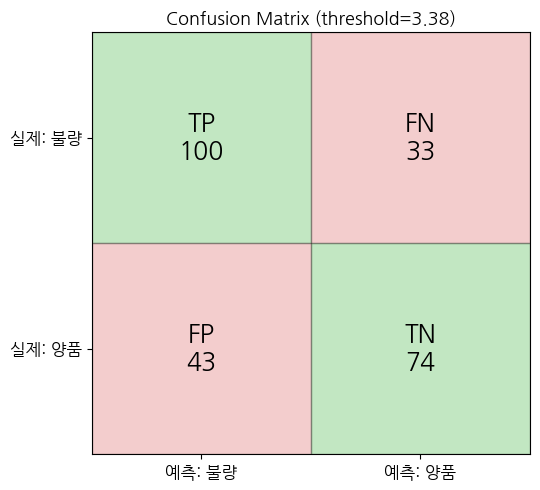

In [36]:
import numpy as np
import matplotlib.pyplot as plt

if 'scored' in globals():
    src_df = scored.dropna(subset=['이상점수'])
elif 'df' in globals():
    src_df = df.dropna(subset=['이상점수'])
else:
    raise NameError("df 또는 scored가 없음 — held-out 검증 셀을 먼저 실행하세요")

def best_threshold(d, n=100):
    ths = np.linspace(d['이상점수'].min(), d['이상점수'].max(), n)
    best_acc, best_th = -1, ths[0]
    for th in ths:
        pred_bad = d['이상점수'] > th
        actual_bad = d['실제'] == '불량'
        acc = (pred_bad == actual_bad).mean()
        if acc > best_acc:
            best_acc, best_th = acc, th
    return best_th, best_acc

if 'sweep' in globals() and len(sweep):
    TH = sweep.loc[sweep.accuracy.idxmax(), 'threshold']
elif 'sweep_all' in globals() and len(sweep_all):
    TH = sweep_all.loc[sweep_all.accuracy.idxmax(), 'threshold']
else:
    TH, acc0 = best_threshold(src_df)
    print(f"threshold 자동 계산: {TH:.2f} (accuracy {acc0:.1%})")

pred_bad = src_df['이상점수'] > TH
actual_bad = src_df['실제'] == '불량'

TP = int((pred_bad & actual_bad).sum())
FN = int((~pred_bad & actual_bad).sum())
FP = int((pred_bad & ~actual_bad).sum())
TN = int((~pred_bad & ~actual_bad).sum())

print(f"threshold = {TH:.2f}  (이상점수 > TH → 불량 판정)\n")
print(f"TP (실제 불량, 불량 판정 · 정탐) : {TP}")
print(f"FN (실제 불량, 양품 판정 · 놓침) : {FN}   ← (0이 목표)")
print(f"FP (실제 양품, 불량 판정 · 과검) : {FP}")
print(f"TN (실제 양품, 양품 판정 · 정탐) : {TN}")

accuracy = (TP+TN)/(TP+FN+FP+TN)
recall = TP/(TP+FN) if TP+FN else 0
precision = TP/(TP+FP) if TP+FP else 0
print(f"\naccuracy={accuracy:.1%}  recall(불량검출률)={recall:.1%}  precision={precision:.1%}")

fig, ax = plt.subplots(figsize=(5.5, 5))
cell_data = [
    [('TP', TP, '#0ca30c'), ('FN', FN, '#d03b3b')],
    [('FP', FP, '#d03b3b'), ('TN', TN, '#0ca30c')],
]
for i in range(2):
    for j in range(2):
        name, val, color = cell_data[i][j]
        ax.add_patch(plt.Rectangle((j, 1-i), 1, 1, facecolor=color, alpha=0.25, edgecolor='black'))
        ax.text(j+0.5, 1-i+0.5, f"{name}\n{val}", ha='center', va='center', fontsize=18, fontweight='bold')

ax.set_xlim(0, 2); ax.set_ylim(0, 2)
ax.set_xticks([0.5, 1.5]); ax.set_xticklabels(['예측: 불량', '예측: 양품'], fontsize=12)
ax.set_yticks([0.5, 1.5]); ax.set_yticklabels(['실제: 양품', '실제: 불량'], fontsize=12)
ax.set_title(f'Confusion Matrix (threshold={TH:.2f})', fontsize=13)
plt.tight_layout()
plt.show()

메모리 뱅크 shape: (74400, 1536)


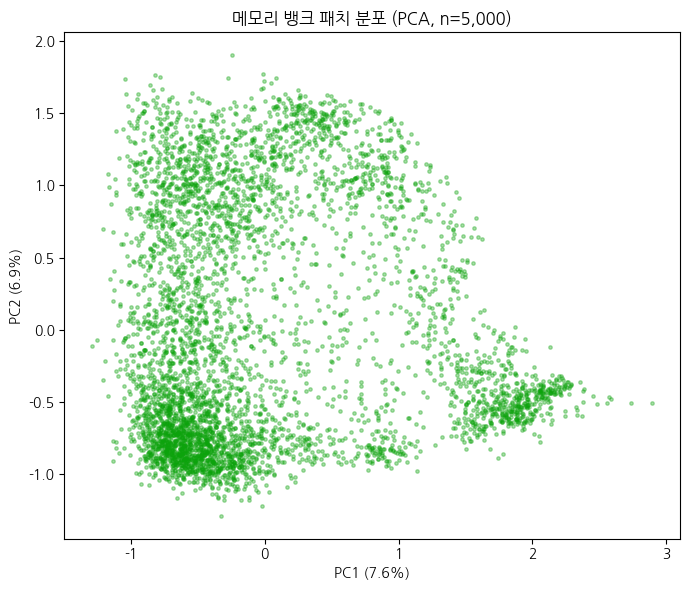

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

assert 'memory_bank' in globals(), "memory_bank 없음 - 메모리 뱅크 구축 셀 먼저 실행"

mb_np = memory_bank.detach().cpu().numpy()
print(f"메모리 뱅크 shape: {mb_np.shape}")

MAX_POINTS = 5000
if mb_np.shape[0] > MAX_POINTS:
    idx = np.random.choice(mb_np.shape[0], MAX_POINTS, replace=False)
    mb_sample = mb_np[idx]
else:
    mb_sample = mb_np

pca = PCA(n_components=2, random_state=42)
mb_2d = pca.fit_transform(mb_sample)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(mb_2d[:, 0], mb_2d[:, 1], s=6, alpha=0.35, color='#0ca30c')
ax.set_title(f'메모리 뱅크 패치 분포 (PCA, n={len(mb_sample):,})')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.tight_layout()
plt.show()

In [40]:
import random

random.seed(42)
shuffled_good = good_paths.copy()
random.shuffle(shuffled_good)
split = int(len(shuffled_good) * 0.8)
bank_good = shuffled_good[:split]
val_good = shuffled_good[split:]
print(f"뱅크용 {len(bank_good)}장 / 검증용(held-out) {len(val_good)}장")

뱅크용 93장 / 검증용(held-out) 24장


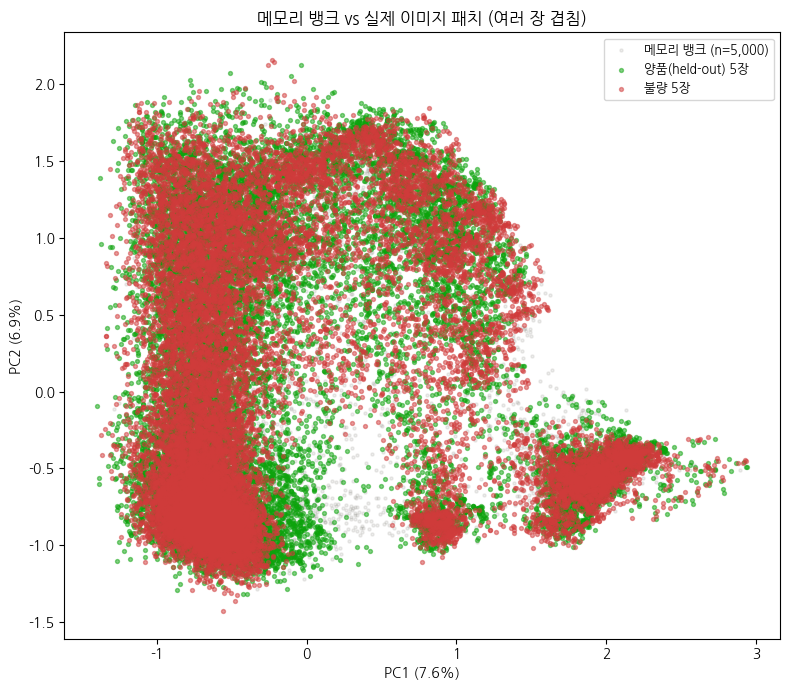

In [41]:
assert all(v in globals() for v in ['pca', 'mb_2d', 'mb_sample', 'extractor']), \
    "이전 PCA 셀(메모리 뱅크 점구름 그리던 셀)을 먼저 실행하세요"

def extract_all_patches(path, size=PATCH_INPUT_SIZE):
    x, _ = load_for_patchcore(path, size=size)
    feat = extractor(x)
    B, C, H, W = feat.shape
    return feat.permute(0, 2, 3, 1).reshape(H*W, C).cpu().numpy()

N_SAMPLE = 5
good_sample_paths = (val_good if 'val_good' in globals() and len(val_good) else good_paths)[:N_SAMPLE]
bad_sample_paths = bad_paths[:N_SAMPLE]

good_2d_all = np.vstack([pca.transform(extract_all_patches(p)) for p in good_sample_paths])
bad_2d_all = np.vstack([pca.transform(extract_all_patches(p)) for p in bad_sample_paths])

fig, ax = plt.subplots(figsize=(8, 7))
ax.scatter(mb_2d[:, 0], mb_2d[:, 1], s=5, alpha=0.15, color='#888780', label=f'메모리 뱅크 (n={len(mb_sample):,})')
ax.scatter(good_2d_all[:, 0], good_2d_all[:, 1], s=8, alpha=0.5, color='#0ca30c', label=f'양품(held-out) {len(good_sample_paths)}장')
ax.scatter(bad_2d_all[:, 0], bad_2d_all[:, 1], s=8, alpha=0.5, color='#d03b3b', label=f'불량 {len(bad_sample_paths)}장')
ax.set_title('메모리 뱅크 vs 실제 이미지 패치 (여러 장 겹침)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

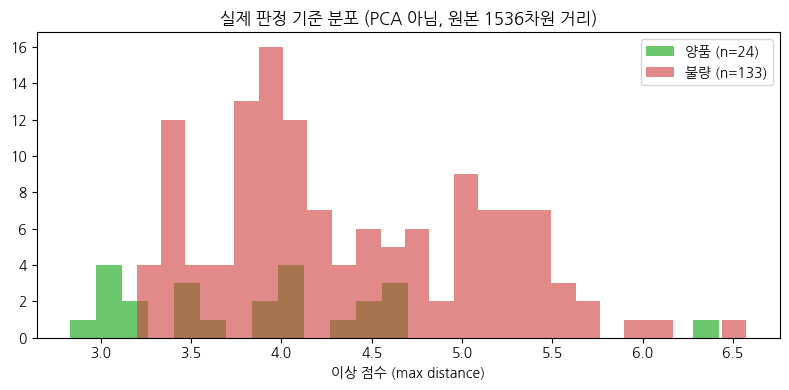

In [42]:
scores_good, scores_bad = [], []
for p in val_good:
    _, s, _ = patchcore_score(p, memory_bank, extractor)
    scores_good.append(s)
for p in bad_paths:
    _, s, _ = patchcore_score(p, memory_bank, extractor)
    scores_bad.append(s)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(scores_good, bins=25, alpha=0.6, color='#0ca30c', label=f'양품 (n={len(scores_good)})')
ax.hist(scores_bad, bins=25, alpha=0.6, color='#d03b3b', label=f'불량 (n={len(scores_bad)})')
ax.set_xlabel('이상 점수 (max distance)'); ax.legend()
ax.set_title('실제 판정 기준 분포 (PCA 아님, 원본 1536차원 거리)')
plt.tight_layout(); plt.show()

In [43]:
import torchvision.transforms as T

aug_transform = T.Compose([
    T.RandomRotation(8),
    T.ColorJitter(brightness=0.15, contrast=0.15),
])

def load_for_patchcore_aug(path, size=PATCH_INPUT_SIZE, augment=False):
    img = Image.open(path).convert("RGB")
    img = img.resize((size, size), Image.BILINEAR)
    if augment:
        img = aug_transform(img)
    return TF.to_tensor(img).unsqueeze(0).to(DEVICE)

def build_bank_augmented(extractor, patch_size, bank_paths, per_image=1500, n_views=3, batch_size=4):
    raw = []
    for view in range(n_views):
        augment = (view > 0)  # 첫 view는 원본 그대로, 나머지는 증강
        for i in range(0, len(bank_paths), batch_size):
            batch = bank_paths[i:i+batch_size]
            imgs = torch.cat([load_for_patchcore_aug(p, size=patch_size, augment=augment) for p in batch], dim=0)
            feats = extractor(imgs)
            B, C, H, W = feats.shape
            feats = feats.permute(0,2,3,1).reshape(B, H*W, C)
            for b in range(B):
                n = min(per_image, H*W)
                raw.append(feats[b, torch.randperm(H*W)[:n]].cpu())
        print(f"view {view+1}/{n_views} 완료")
    return torch.cat(raw, dim=0).to(DEVICE)

memory_bank_aug = build_bank_augmented(extractor, PATCH_INPUT_SIZE, bank_good)
print(f"증강 메모리 뱅크: {tuple(memory_bank_aug.shape)} (기존 대비 패치 다양성 확장)")

view 1/3 완료
view 2/3 완료
view 3/3 완료
증강 메모리 뱅크: (418500, 1536) (기존 대비 패치 다양성 확장)


In [44]:
results = []
for label, paths in [('양품', val_good), ('불량', bad_paths)]:
    for p in paths:
        _, score, _ = patchcore_score(p, memory_bank_aug, extractor)
        results.append({'파일': os.path.basename(p), '실제': label, '이상점수': score})

df_aug = pd.DataFrame(results)
sweep_aug = sweep_threshold(df_aug)
print(f"증강 뱅크 held-out accuracy: {sweep_aug.accuracy.max():.1%}  (기존 69%와 비교)")

증강 뱅크 held-out accuracy: 89.8%  (기존 69%와 비교)


In [45]:
display(sweep_aug.sort_values('accuracy', ascending=False).head(10))

,threshold,accuracy,불량_recall,놓친_불량,과검_양품
10,2.90,0.898,1.000,0,16
9,2.81,0.898,1.000,0,16
11,3.00,0.892,0.985,2,15
8,2.71,0.892,1.000,0,17
6,2.52,0.885,1.000,0,18
5,2.43,0.885,1.000,0,18
7,2.62,0.885,1.000,0,18
4,2.34,0.885,1.000,0,18
3,2.24,0.885,1.000,0,18
12,3.09,0.879,0.962,5,14


In [ ]:
results_full = []
for label, paths in [('양품', val_good), ('불량', bad_paths)]:  # bad_paths 전체 133장
    for p in paths:
        _, score, _ = patchcore_score(p, memory_bank_aug, extractor)
        results_full.append({'파일': os.path.basename(p), '실제': label, '이상점수': score})

df_aug_full = pd.DataFrame(results_full)
sweep_aug_full = sweep_threshold(df_aug_full)
print(f"불량 전체(133장) 기준 accuracy: {sweep_aug_full.accuracy.max():.1%}")